## Load Data

In [1]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

df_train=pd.read_csv('train.csv')
df_train

,ID,date,cluster_id,electricity_consumption,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,sunshine_duration,daylight_duration,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,shortwave_radiation_sum,et0_fao_evapotranspiration
0,cluster_1_2014-01-01,2014-01-01,cluster_1,358.032,10.8,4.2,5.5,0.4,53.003333,29787.533333,40.6,79.2,186.000000,1.176667,0.483333
1,cluster_2_2014-01-01,2014-01-01,cluster_2,548.247,12.2,4.3,8.6,-0.4,8195.656667,30650.350000,36.0,81.7,170.591118,3.383333,0.736667
2,cluster_3_2014-01-01,2014-01-01,cluster_3,758.303,12.9,-0.8,10.1,-4.9,16305.260000,31547.686667,20.9,44.3,159.467752,3.880000,0.716667
3,cluster_4_2014-01-01,2014-01-01,cluster_4,1072.077,10.8,4.7,6.7,0.6,9224.803333,30769.220000,34.7,82.8,184.339753,3.153333,0.676667
4,cluster_1_2014-01-02,2014-01-02,cluster_1,386.908,10.7,7.0,6.6,3.3,22372.000000,29850.226667,34.3,75.2,210.333465,3.640000,0.780000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11683,cluster_4_2021-12-30,2021-12-30,cluster_4,994.158,14.9,7.7,15.6,6.2,16136.066667,30666.253333,22.8,42.8,263.384394,3.563333,0.590000
11684,cluster_1_2021-12-31,2021-12-31,cluster_1,354.565,14.7,7.7,13.4,5.2,19148.153333,29727.200000,20.7,37.4,201.332279,3.510000,0.513333
11685,cluster_2_2021-12-31,2021-12-31,cluster_2,507.510,16.2,7.0,16.3,4.5,20570.920000,30594.280000,23.3,40.7,186.250597,5.006667,0.733333
11686,cluster_3_2021-12-31,2021-12-31,cluster_3,705.999,15.9,5.9,15.9,3.2,26860.350000,31496.173333,15.1,27.7,196.223902,5.783333,0.720000


## EDA

In [2]:
df_train['cluster_id'].value_counts()

cluster_id
cluster_1    2922
cluster_2    2922
cluster_3    2922
cluster_4    2922
Name: count, dtype: int64

In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11688 entries, 0 to 11687
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           11688 non-null  object 
 1   date                         11688 non-null  object 
 2   cluster_id                   11688 non-null  object 
 3   electricity_consumption      11688 non-null  float64
 4   temperature_2m_max           11688 non-null  float64
 5   temperature_2m_min           11688 non-null  float64
 6   apparent_temperature_max     11688 non-null  float64
 7   apparent_temperature_min     11688 non-null  float64
 8   sunshine_duration            11688 non-null  float64
 9   daylight_duration            11688 non-null  float64
 10  wind_speed_10m_max           11688 non-null  float64
 11  wind_gusts_10m_max           11688 non-null  float64
 12  wind_direction_10m_dominant  11688 non-null  float64
 13  shortwave_radiat

In [4]:
df_train.isna().sum()

ID                             0
date                           0
cluster_id                     0
electricity_consumption        0
temperature_2m_max             0
temperature_2m_min             0
apparent_temperature_max       0
apparent_temperature_min       0
sunshine_duration              0
daylight_duration              0
wind_speed_10m_max             0
wind_gusts_10m_max             0
wind_direction_10m_dominant    0
shortwave_radiation_sum        0
et0_fao_evapotranspiration     0
dtype: int64

In [3]:
df_train.duplicated().sum()

0

In [5]:
df_train.describe()

,electricity_consumption,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,sunshine_duration,daylight_duration,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,shortwave_radiation_sum,et0_fao_evapotranspiration
count,11688.000000,11688.000000,11688.000000,11688.000000,11688.000000,11688.000000,11688.000000,11688.000000,11688.000000,11688.000000,11688.000000,11688.000000
mean,642.313328,18.733385,7.174786,17.215315,4.784608,29302.656241,44070.779592,23.273058,46.420115,202.335554,12.742257,2.428585
std,287.673473,7.504161,5.960263,9.085303,7.260336,13600.113712,9283.839471,7.993389,15.226372,100.697741,7.588077,1.607845
min,207.472000,-1.900000,-10.800000,-8.100000,-15.400000,0.000000,29447.550000,6.800000,13.300000,0.002855,0.333333,0.173333
25%,414.376000,12.800000,2.500000,10.000000,-1.100000,19104.170833,35150.501667,17.400000,35.300000,134.384708,5.600000,0.990000
50%,602.672000,18.200000,7.100000,16.400000,4.400000,29917.360000,44185.056667,22.000000,43.900000,219.000000,12.140000,2.156667
75%,836.034500,24.300000,12.100000,24.000000,10.800000,40697.756667,52997.815833,28.000000,54.700000,281.609519,18.924167,3.616667
max,1658.348000,40.900000,23.200000,42.600000,23.800000,53498.910000,58501.420000,63.900000,126.700000,360.000000,29.983333,8.133333


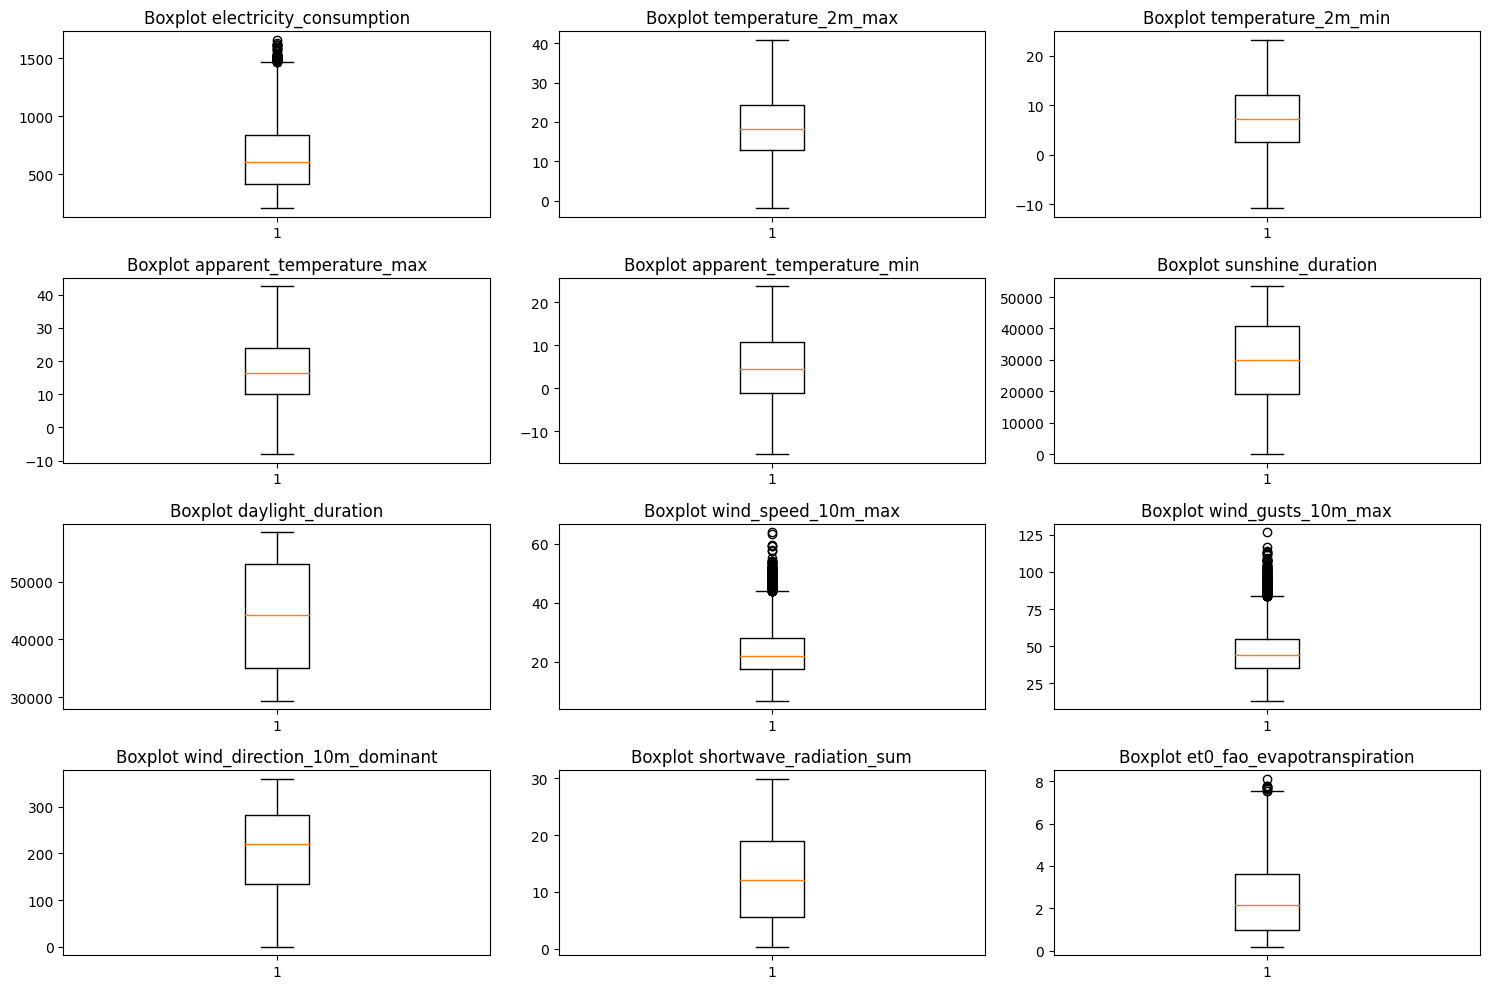

In [4]:
import matplotlib.pyplot as plt

num=df_train.select_dtypes(include=['number']).columns.tolist()

fig,ax=plt.subplots(4,3,figsize=(15,10))
ax=ax.flat
for i,cols in enumerate(num):
    ax[i].boxplot(df_train[cols])
    ax[i].set_title(f'Boxplot {cols}')

plt.tight_layout()
plt.show()

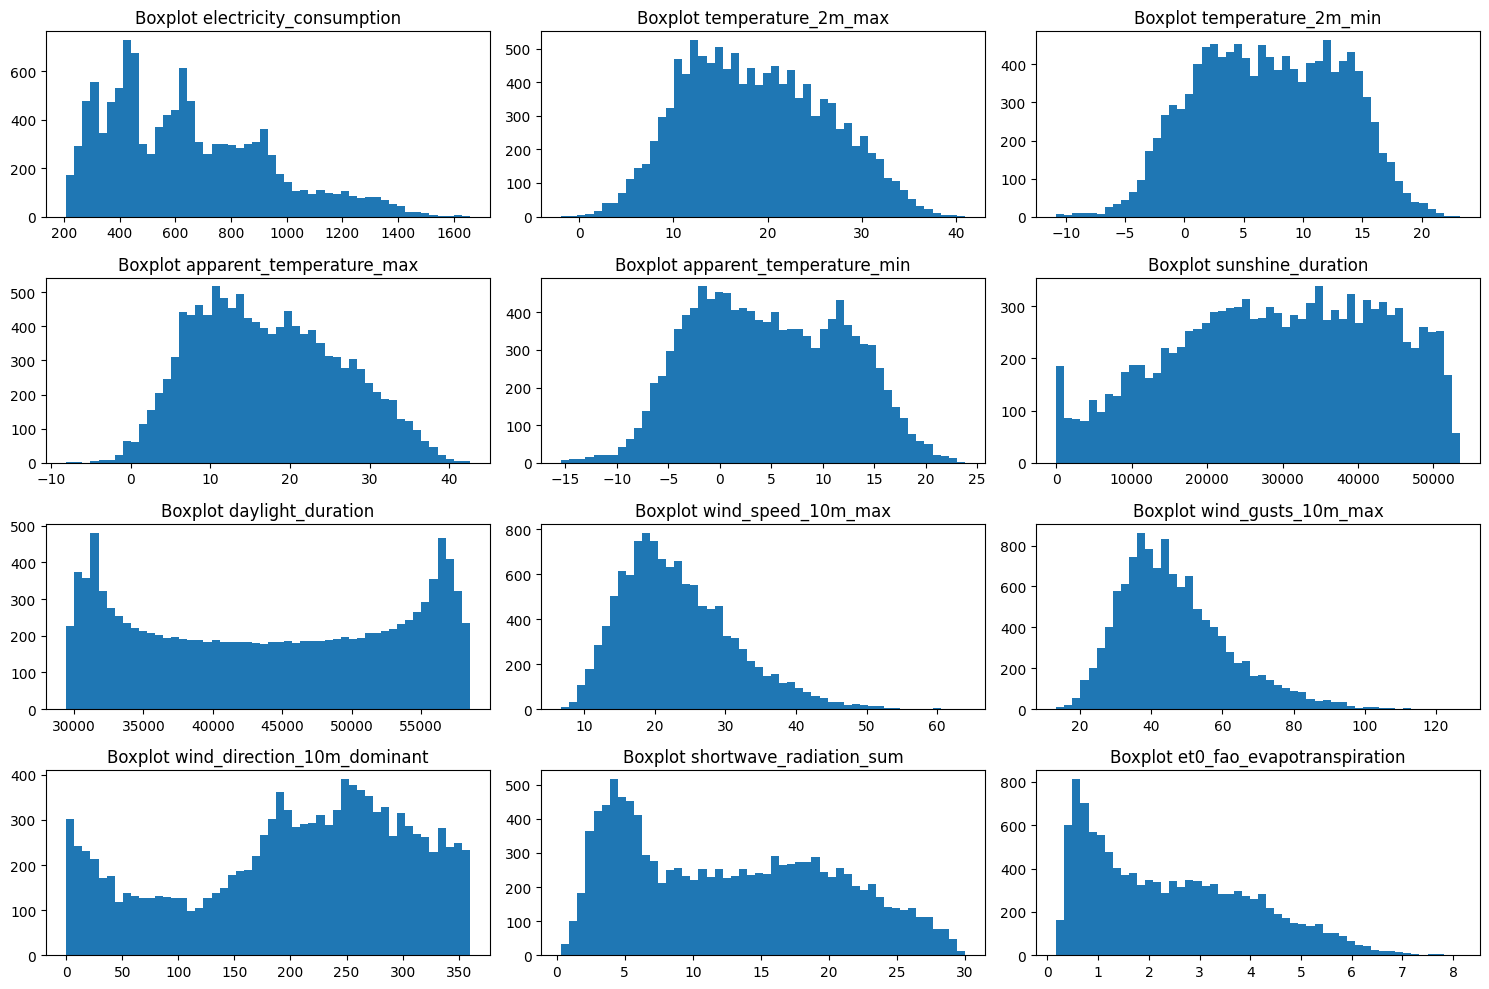

In [8]:
fig,ax=plt.subplots(4,3,figsize=(15,10))
ax=ax.flat
for i,cols in enumerate(num):
    ax[i].hist(df_train[cols],bins=50)
    ax[i].set_title(f'Boxplot {cols}')

plt.tight_layout()
plt.show()

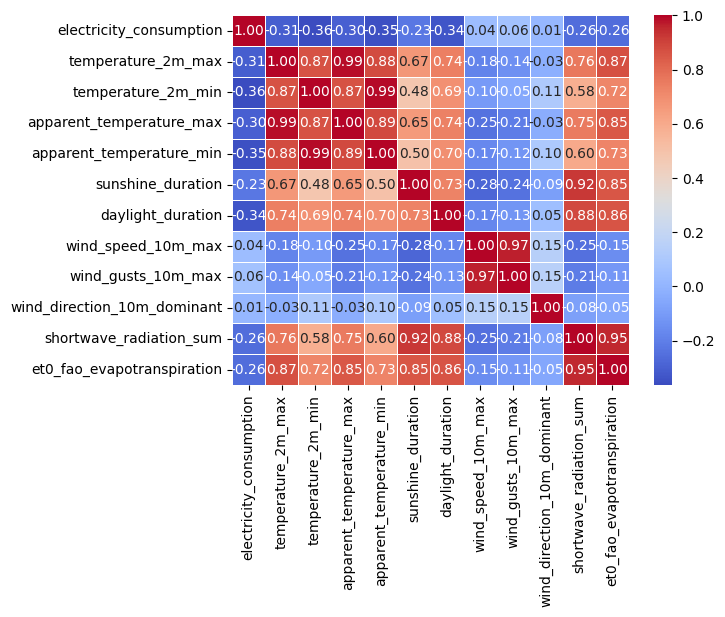

In [9]:
import seaborn as sns

correlation=df_train[num].corr()

sns.heatmap(data=correlation,annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.5,linecolor='white')
plt.show()

## Data Pre-processing

In [5]:
df_train_clean=df_train.copy()

In [6]:
df_train_clean=df_train_clean.sort_values(by='date').reset_index(drop=True)
df_train_clean

,ID,date,cluster_id,electricity_consumption,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,sunshine_duration,daylight_duration,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,shortwave_radiation_sum,et0_fao_evapotranspiration
0,cluster_1_2014-01-01,2014-01-01,cluster_1,358.032,10.8,4.2,5.5,0.4,53.003333,29787.533333,40.6,79.2,186.000000,1.176667,0.483333
1,cluster_2_2014-01-01,2014-01-01,cluster_2,548.247,12.2,4.3,8.6,-0.4,8195.656667,30650.350000,36.0,81.7,170.591118,3.383333,0.736667
2,cluster_3_2014-01-01,2014-01-01,cluster_3,758.303,12.9,-0.8,10.1,-4.9,16305.260000,31547.686667,20.9,44.3,159.467752,3.880000,0.716667
3,cluster_4_2014-01-01,2014-01-01,cluster_4,1072.077,10.8,4.7,6.7,0.6,9224.803333,30769.220000,34.7,82.8,184.339753,3.153333,0.676667
4,cluster_1_2014-01-02,2014-01-02,cluster_1,386.908,10.7,7.0,6.6,3.3,22372.000000,29850.226667,34.3,75.2,210.333465,3.640000,0.780000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11683,cluster_2_2021-12-30,2021-12-30,cluster_2,494.063,14.4,8.1,14.2,6.4,9329.206667,30546.000000,28.7,49.0,203.924718,2.923333,0.586667
11684,cluster_2_2021-12-31,2021-12-31,cluster_2,507.510,16.2,7.0,16.3,4.5,20570.920000,30594.280000,23.3,40.7,186.250597,5.006667,0.733333
11685,cluster_3_2021-12-31,2021-12-31,cluster_3,705.999,15.9,5.9,15.9,3.2,26860.350000,31496.173333,15.1,27.7,196.223902,5.783333,0.720000
11686,cluster_1_2021-12-31,2021-12-31,cluster_1,354.565,14.7,7.7,13.4,5.2,19148.153333,29727.200000,20.7,37.4,201.332279,3.510000,0.513333


In [7]:
from sklearn.preprocessing import FunctionTransformer

def date_feat(df):
    df['date']=pd.to_datetime(df['date'])

    df['year']=df['date'].dt.year
    df['month']=df['date'].dt.month
    df['day']=df['date'].dt.day

    df['day_of_week'] = df['date'].dt.dayofweek
    df['is_weekend'] = df['date'].dt.dayofweek.isin([5, 6]).astype(int)

    df['quarter'] = df['date'].dt.quarter

    return df.drop(columns=['date','ID'])

date_transformer=FunctionTransformer(date_feat)

In [8]:
x_train=df_train_clean.drop(columns=['electricity_consumption'])
y_train=df_train_clean['electricity_consumption']

In [9]:
x_train

,ID,date,cluster_id,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,sunshine_duration,daylight_duration,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,shortwave_radiation_sum,et0_fao_evapotranspiration
0,cluster_1_2014-01-01,2014-01-01,cluster_1,10.8,4.2,5.5,0.4,53.003333,29787.533333,40.6,79.2,186.000000,1.176667,0.483333
1,cluster_2_2014-01-01,2014-01-01,cluster_2,12.2,4.3,8.6,-0.4,8195.656667,30650.350000,36.0,81.7,170.591118,3.383333,0.736667
2,cluster_3_2014-01-01,2014-01-01,cluster_3,12.9,-0.8,10.1,-4.9,16305.260000,31547.686667,20.9,44.3,159.467752,3.880000,0.716667
3,cluster_4_2014-01-01,2014-01-01,cluster_4,10.8,4.7,6.7,0.6,9224.803333,30769.220000,34.7,82.8,184.339753,3.153333,0.676667
4,cluster_1_2014-01-02,2014-01-02,cluster_1,10.7,7.0,6.6,3.3,22372.000000,29850.226667,34.3,75.2,210.333465,3.640000,0.780000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11683,cluster_2_2021-12-30,2021-12-30,cluster_2,14.4,8.1,14.2,6.4,9329.206667,30546.000000,28.7,49.0,203.924718,2.923333,0.586667
11684,cluster_2_2021-12-31,2021-12-31,cluster_2,16.2,7.0,16.3,4.5,20570.920000,30594.280000,23.3,40.7,186.250597,5.006667,0.733333
11685,cluster_3_2021-12-31,2021-12-31,cluster_3,15.9,5.9,15.9,3.2,26860.350000,31496.173333,15.1,27.7,196.223902,5.783333,0.720000
11686,cluster_1_2021-12-31,2021-12-31,cluster_1,14.7,7.7,13.4,5.2,19148.153333,29727.200000,20.7,37.4,201.332279,3.510000,0.513333


## Training

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler,OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

num=x_train.select_dtypes(include=['number']).columns.tolist()
cat=['cluster_id']

ct=ColumnTransformer([
    ('oe',OrdinalEncoder(),cat),
    ('rs',RobustScaler(),num)
],remainder='passthrough')

models={
    'LinReg':Pipeline([
        ('dt',date_transformer),
        ('ct',ct),
        ('linreg',LinearRegression())
    ]),
    'RF':Pipeline([
        ('dt',date_transformer),
        ('ct',ct),
        ('rf',RandomForestRegressor(random_state=42))
    ]),
    'XGBR':Pipeline([
        ('dt',date_transformer),
        ('ct',ct),
        ('xgbr',XGBRegressor(random_state=42))
    ])
}

In [11]:
from sklearn.model_selection import cross_validate,TimeSeriesSplit

results={}

tscv=TimeSeriesSplit()
for name,model in models.items():
    scores=cross_validate(
        model,
        x_train,
        y_train,
        cv=tscv,
        scoring=['neg_mean_absolute_error','r2','neg_root_mean_squared_error'],
        n_jobs=-1
    )

    results[name]={
        'MAE_mean':abs(scores['test_neg_mean_absolute_error'].mean()),
        'R2':scores['test_r2'].mean(),
        'RMSE_mean': abs(scores['test_neg_root_mean_squared_error'].mean()),
        'RMSE_std': scores['test_neg_root_mean_squared_error'].std()
    }

In [12]:
df_results=pd.DataFrame(results)
df_results

,LinReg,RF,XGBR
MAE_mean,57.753296,27.088223,26.828264
R2,0.929466,0.979918,0.980883
RMSE_mean,74.026408,39.345687,38.397664
RMSE_std,6.991705,4.221509,3.934830


In [11]:
from sklearn.model_selection import RandomizedSearchCV

params={
    'RF':{
            'rf__n_estimators': [100, 200, 300, 500],
            'rf__max_depth': [None, 10, 20, 30],
            'rf__min_samples_split': [2, 5, 10],
            'rf__min_samples_leaf': [1, 2, 4],
            'rf__max_features': ['sqrt', 'log2', None] 
    },
    'XGBR':{
            'xgbr__n_estimators': [100, 300, 500],
            'xgbr__max_depth': [3, 5, 7, 9],
            'xgbr__learning_rate': [0.01, 0.05, 0.1],
            'xgbr__subsample': [0.7, 0.8, 0.9],
            'xgbr__colsample_bytree': [0.7, 0.8, 0.9]
    }
}

results={}

for name,model in models.items():
    if name in params:

        random=RandomizedSearchCV(
            estimator=model,
            param_distributions=params[name],
            n_iter=10,
            cv=tscv,
            scoring='neg_mean_absolute_error',
            random_state=42,
            n_jobs=-1
        )

        random.fit(x_train,y_train)

        results[name]={
            'params':random.best_params_,
            'MAE':abs(random.best_score_)
        }

In [12]:
df_results=pd.DataFrame(results)
df_results

,RF,XGBR
params,"{'rf__n_estimators': 300, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 2, 'rf__max_features': None, 'rf__max_depth': 30}","{'xgbr__subsample': 0.9, 'xgbr__n_estimators': 300, 'xgbr__max_depth': 5, 'xgbr__learning_rate': 0.05, 'xgbr__colsample_bytree': 0.9}"
MAE,26.85794,24.373204


In [13]:
import joblib

model_params={
    'subsample':0.9,
    'n_estimators':300,
    'max_depth':5,
    'learning_rate':0.05,
    'colsample_bytree':0.9
}

best_model=Pipeline([
    ('dt',date_transformer),
    ('ct',ct),
    ('xgbr',XGBRegressor(**model_params))
])

best_model.fit(x_train,y_train)

joblib.dump(best_model,'model.pkl')

['model.pkl']

## Evaluation

In [14]:
df_test=pd.read_csv('test.csv')
df_test

,ID,date,cluster_id,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,sunshine_duration,daylight_duration,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,shortwave_radiation_sum,et0_fao_evapotranspiration
0,cluster_1_2022-01-01,2022-01-01,cluster_1,15.2,7.9,14.2,5.2,21902.986667,29784.506667,22.2,37.8,172.732245,4.173333,0.780000
1,cluster_2_2022-01-01,2022-01-01,cluster_2,15.9,4.1,15.3,1.3,23550.080000,30647.540000,22.7,38.5,163.972679,5.146667,0.730000
2,cluster_3_2022-01-01,2022-01-01,cluster_3,18.6,4.9,18.8,1.8,24179.643333,31545.103333,15.5,26.3,198.645137,5.713333,0.730000
3,cluster_4_2022-01-01,2022-01-01,cluster_4,13.3,3.9,11.9,1.3,23839.203333,30766.446667,16.1,27.4,183.517316,4.200000,0.486667
4,cluster_1_2022-01-02,2022-01-02,cluster_1,14.1,8.1,11.2,5.3,21018.193333,29847.110000,34.4,59.4,223.335840,4.030000,1.170000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3395,cluster_4_2024-04-28,2024-04-28,cluster_4,15.5,8.7,12.9,5.7,18456.970000,51576.863333,32.4,67.0,195.650367,10.720000,1.950000
3396,cluster_1_2024-04-29,2024-04-29,cluster_1,17.5,4.2,16.0,1.8,42380.410000,52371.786667,19.6,39.6,178.686641,18.860000,2.886667
3397,cluster_2_2024-04-29,2024-04-29,cluster_2,17.5,5.3,16.5,3.1,25459.183333,51830.010000,22.1,41.8,207.350466,14.960000,2.350000
3398,cluster_3_2024-04-29,2024-04-29,cluster_3,21.2,7.3,19.6,5.1,27659.363333,51270.046667,25.1,47.2,345.268483,17.090000,3.163333


In [ ]:
load_model=joblib.load('model.pkl')

pred=load_model.predict(df_test)

array([313.1407 , 509.60516, 660.0195 , ..., 453.4396 , 606.3682 ,
       924.12274], dtype=float32)

In [17]:
df_submisison=pd.DataFrame({
    'ID':df_test['ID'],
    'electricity_consumption':pred
})
df_submisison

,ID,electricity_consumption
0,cluster_1_2022-01-01,313.140686
1,cluster_2_2022-01-01,509.605164
2,cluster_3_2022-01-01,660.019470
3,cluster_4_2022-01-01,965.700867
4,cluster_1_2022-01-02,356.977295
...,...,...
3395,cluster_4_2024-04-28,829.998413
3396,cluster_1_2024-04-29,317.876282
3397,cluster_2_2024-04-29,453.439606
3398,cluster_3_2024-04-29,606.368225


In [18]:
df_submisison.to_csv('result.csv',index=False)